# **Linear Regression from Scratch with more features**

### 1. Import the Essential libraries

In [83]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray
import matplotlib.pyplot as plt




### 2. Read the data from csv file 


In [84]:
data = pd.read_csv("data2.csv")

## 3. Plot the Relation of Price with each features

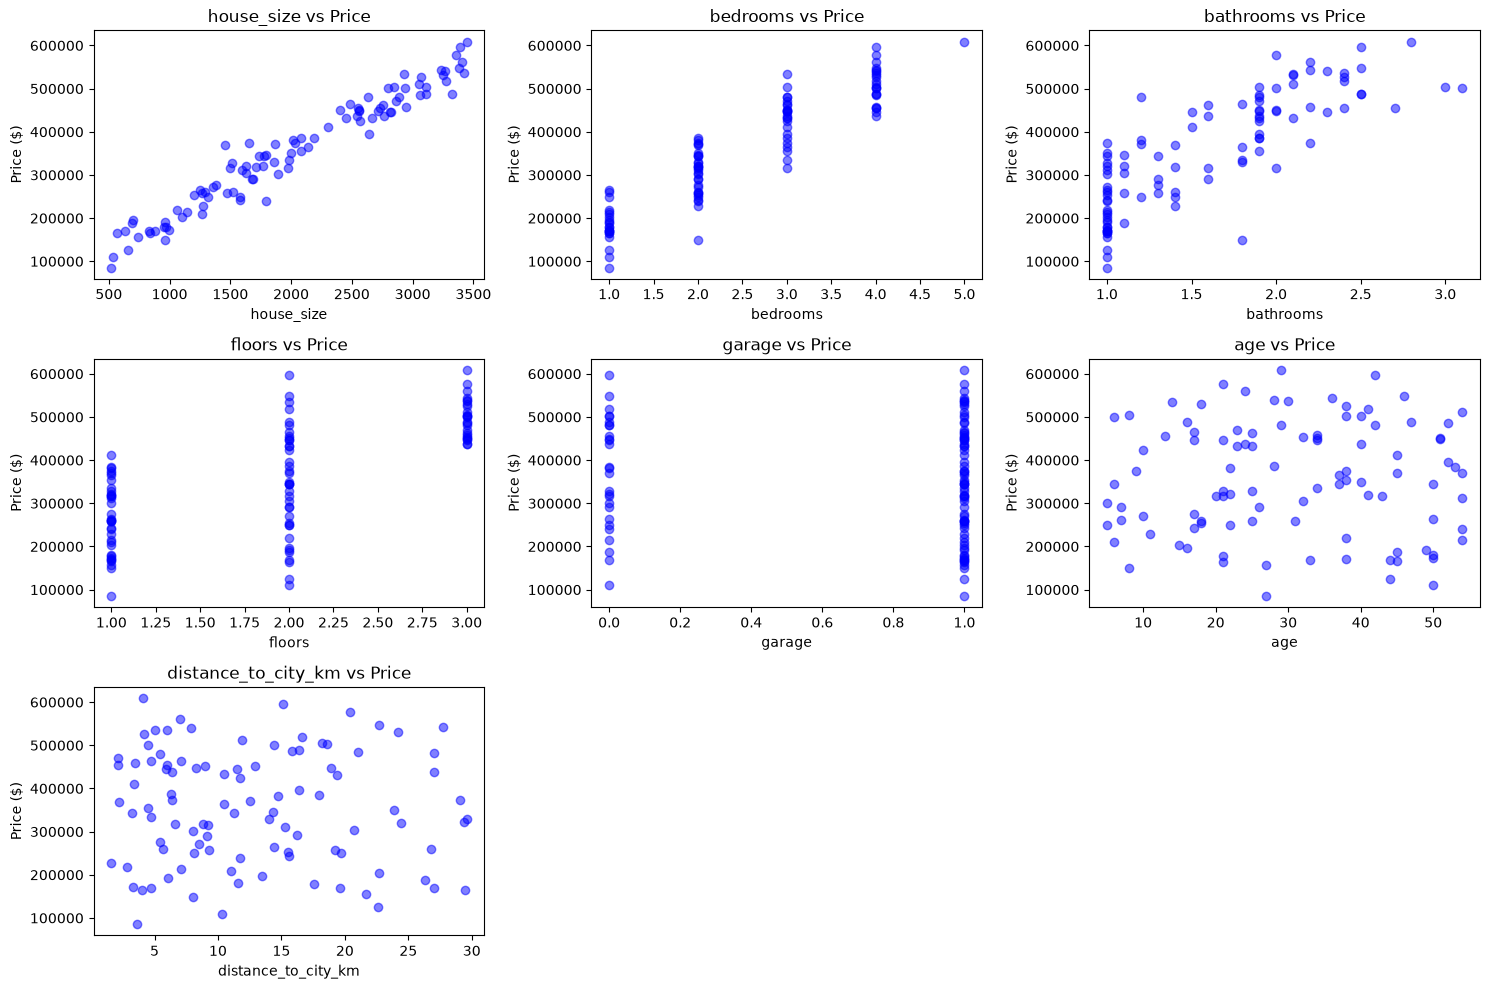

In [85]:

features = ["house_size", "bedrooms", "bathrooms", "floors", "garage", "age", "distance_to_city_km"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(data[feature], data["price"], alpha=0.5, color="blue")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price ($)")
    axes[i].set_title(f"{feature} vs Price")

# hide the 2 empty subplots (3x3 = 9 slots, we have 7 features)
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.show()

### 3. Define a normalize function 
#### Normalization (Min-Max)

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Squeezes any range down to **0 – 1**.

---

#### Denormalization (reverse it)

$$x = x_{norm} \times (x_{max} - x_{min}) + x_{min}$$

Stretches it back to the **original range**.

---

In [86]:
def min_max_normalization(array : NDArray) -> NDArray:
        return (array - np.min(array)) / (np.max(array) - np.min(array))
def min_max_denormalization(array : NDArray , array_norm: NDArray) -> NDArray:
        return array_norm * (np.max(array) - np.min(array)) + np.min(array)
        # Y_predict_norm * (Y_raw.max() - Y_raw.min()) + Y_raw.min()



## 4. Elimianting features that has no effect
* looking at the plots it is found out that the distance ,  no of garages and age has no effect on the price 
* take the 80% of data for training


In [87]:
features = ["house_size", "bedrooms", "bathrooms", "floors" ,"price"]
data = data[features]

actual_prices = data["price"][:80]

size_train = data["house_size"][:80]
bedrooms_train = data["bedrooms"][:80]
bathrooms_train = data["bathrooms"][:80]
floors_train = data["floors"][:80]

size_min, size_max         = size_train.min(), size_train.max()
bedrooms_min, bedrooms_max = bedrooms_train.min(), bedrooms_train.max()
bathrooms_min, bathrooms_max = bathrooms_train.min(), bathrooms_train.max()
floors_min, floors_max     = floors_train.min(), floors_train.max()

size_train = min_max_normalization(size_train)
bedrooms_train = min_max_normalization(bedrooms_train)
bathrooms_train = min_max_normalization(bathrooms_train)
floors_train = min_max_normalization(floors_train)

actual_prices = min_max_normalization(actual_prices)



### 4. Actuall implementation

#### Step 2 — Predict

$$\hat{y} = w_1(\text{size}) + w_2(\text{bedrooms}) + w_3(\text{bathrooms}) + w_4(\text{floors}) + b$$
---
#### Step 3 — Measure Error (Cost)

$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2$$
---
#### Step 4 — Compute Gradients

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \cdot x_i$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$$
---
#### Step 5 — Update w and b

$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$
---
| Symbol | Meaning |
|---|---|
| m | number of data points (100) |
| α | learning rate (e.g. 0.01) |
| ŷᵢ | predicted price for sample i |
| yᵢ | actual price for sample i |
| xᵢ | house size for sample i |
| J | cost — one number measuring total error |

In [88]:
w1 , w2 ,w3 ,w4 = 0 , 0, 0, 0
b=0
all_costs=[]
costs = 0
m = 80
while True:
    predited_prices = (w1 * size_train) + (w2 * bedrooms_train) + (w3 * bathrooms_train) + (w4 * floors_train) + b

    error = (1 / (2 * m)) * (np.sum((predited_prices - actual_prices) ** 2))

    j_w1 = (1 / m ) * (np.sum((predited_prices - actual_prices) * size_train))
    j_w2 = (1 / m ) * (np.sum((predited_prices - actual_prices) * bedrooms_train))
    j_w3 = (1 / m ) * (np.sum((predited_prices - actual_prices) * bathrooms_train))
    j_w4 = (1 / m ) * (np.sum((predited_prices - actual_prices) * floors_train))
    j_b = (1 / m) * (np.sum(predited_prices - actual_prices))
    w1 -= 1.068 * j_w1
    w2 -= 1.068 * j_w2
    w3 -= 1.068 * j_w3
    w4 -= 1.068 * j_w4
    b -= 1.068 * j_b
    if abs(costs - error) < 1e-10:
        break
    costs = error
    all_costs.append(error)
print(f"w1     = {w1:.4f}")
print(f"w2     = {w2:.4f}")
print(f"w3     = {w3:.4f}")
print(f"w4     = {w4:.4f}")
print(f"b     = {b:.4f}")
print(f"cost  = {costs}")
# w     = 0.8320
# b     = 0.0864
# cost  = 0.0011882965167950826



# 403696799.376182


w1     = 0.8070
w2     = 0.0128
w3     = 0.0013
w4     = 0.0152
b     = 0.0873
cost  = 0.0014743141807956404


### 5. Tests the predictions on test data & calculatr Mean absolute error
#### Step 6  — Actual prediction

$$\hat{y} = w_1(\text{size}) + w_2(\text{bedrooms}) + w_3(\text{bathrooms}) + w_4(\text{floors}) + b$$
---
#### step 7 — **MAE** (Mean Absolute Error) 

$$MAE = \frac{1}{m} \sum |y_{actual} - y_{predicted}|$$

In [89]:

size_test = data["house_size"][80:]
bedrooms_test = data["bedrooms"][80:]
bathrooms_test = data["bathrooms"][80:]
floors_test = data["floors"][80:]
actual_prices = data["price"][:80]

size_test = min_max_normalization(size_test)
bedrooms_test = min_max_normalization(bedrooms_test)
bathrooms_test = min_max_normalization(bathrooms_test)
floors_test = min_max_normalization(floors_test)

# actual_prices_test = min_max_normalization(actual_prices)

actual_prices_test = data["price"][80:]


predictions =  (w1 * size_test) + (w2 * bedrooms_test) + (w3 * bathrooms_test) + (w4 * floors_test) + b


# denormalize output back to real prices
Y_predict = min_max_denormalization(actual_prices, predictions)

for actual_p , predict_p in zip(actual_prices , Y_predict):
    print(f"Actual : {actual_p} | Predicted : {predict_p}")
mae = np.mean(np.abs(actual_prices_test - Y_predict))
print(f"MAE = ${mae:,.0f}")

Actual : 271463 | Predicted : 192356.0767348705
Actual : 345732 | Predicted : 326673.55712172494
Actual : 321329 | Predicted : 286208.5579929168
Actual : 311899 | Predicted : 500110.6036203756
Actual : 364485 | Predicted : 568749.6678166105
Actual : 431645 | Predicted : 177895.28459695136
Actual : 149655 | Predicted : 260797.44344883607
Actual : 343689 | Predicted : 295665.6129940227
Actual : 169168 | Predicted : 244851.21073981083
Actual : 334988 | Predicted : 489997.3544694817
Actual : 480641 | Predicted : 242747.43496477857
Actual : 535903 | Predicted : 481823.2211954202
Actual : 169543 | Predicted : 180482.17737661017
Actual : 386646 | Predicted : 198136.7908961288
Actual : 209215 | Predicted : 311955.56881709234
Actual : 481375 | Predicted : 456208.42309838685
Actual : 381438 | Predicted : 131267.98924697863
Actual : 576817 | Predicted : 537700.2617245107
Actual : 534813 | Predicted : 341130.14869472996
Actual : 317395 | Predicted : 303481.58945252915
MAE = $24,869


## 6. Plot the Graph of actual and predicted prices

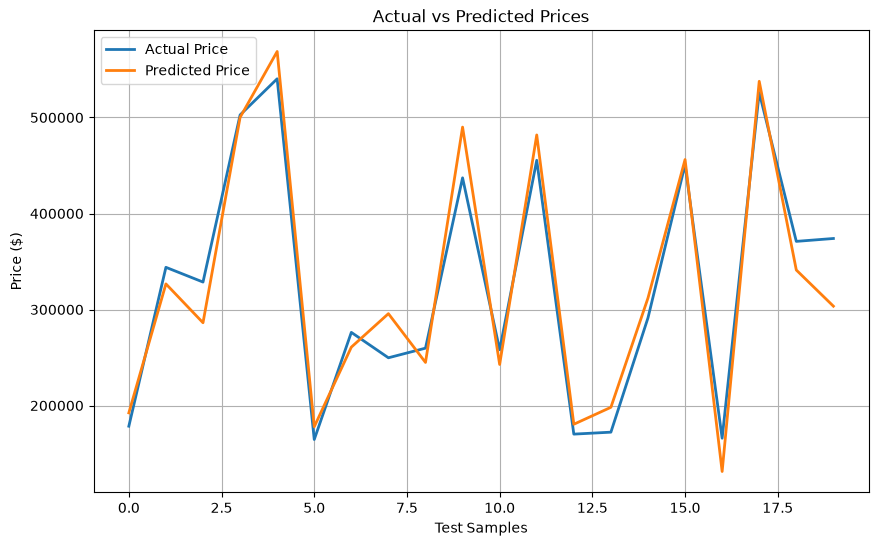

In [90]:


# Flatten arrays
actuals = np.array(actual_prices_test).flatten()
predictions = np.array(Y_predict).flatten()

plt.figure(figsize=(10,6))

plt.plot(actuals, label="Actual Price", linewidth=2)
plt.plot(predictions, label="Predicted Price", linewidth=2)

plt.xlabel("Test Samples")
plt.ylabel("Price ($)")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid(True)

plt.show()

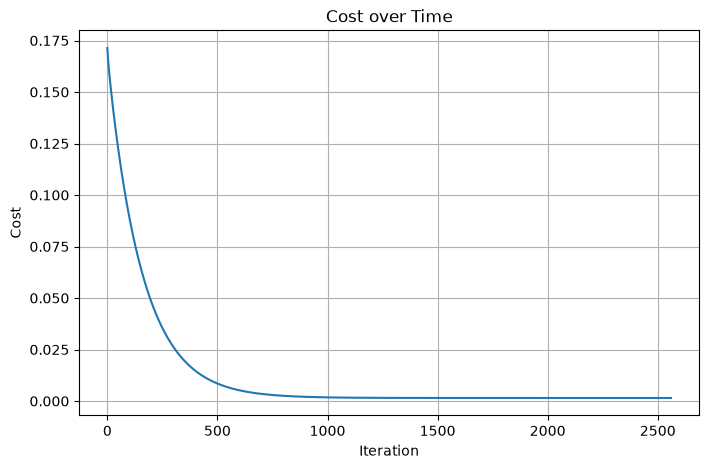

In [91]:


plt.figure(figsize=(8,5))

plt.plot(all_costs)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost over Time")
plt.grid(True)

plt.show()